## Appendix 1: Code and Output

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
import missingno

# Modeling libraries
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier

# Model evaluation libraries
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, roc_auc_score, accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.utils import resample
from scipy import stats
from scipy.stats import zscore

warnings.filterwarnings('ignore')

In [55]:
# Importing the Titanic dataset
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
passenger_id = test_df["PassengerId"]

### 1. Exploratory Data Analysis

In [56]:
# Dataset overview
dataset_info = pd.DataFrame({
    'Dataset': ['Training', 'Test'],
    'Rows': [train_df.shape[0], test_df.shape[0]],
    'Columns': [train_df.shape[1], test_df.shape[1]]
})

print("Dataset Overview:")
display(dataset_info)

data_types_summary = pd.DataFrame({
    'Data_Type': train_df.dtypes.value_counts().index,
    'Count': train_df.dtypes.value_counts().values
})
print("Data Types Summary in Training Dataset:")
display(data_types_summary)

# Missing values analysis
missing_values = pd.DataFrame({
    'Column': train_df.columns,
    'Missing_Count': train_df.isnull().sum().values,
    'Missing_Percentage': (round(train_df.isnull().sum() / len(train_df) * 100, 2)).values
})
print("Missing Values in Training Dataset:")
display(missing_values)

Dataset Overview:


,Dataset,Rows,Columns
0,Training,891,12
1,Test,418,11


Data Types Summary in Training Dataset:


,Data_Type,Count
0,int64,5
1,object,5
2,float64,2


Missing Values in Training Dataset:


,Column,Missing_Count,Missing_Percentage
0,PassengerId,0,0.00
1,Survived,0,0.00
2,Pclass,0,0.00
3,Name,0,0.00
4,Sex,0,0.00
5,Age,177,19.87
6,SibSp,0,0.00
7,Parch,0,0.00
8,Ticket,0,0.00
9,Fare,0,0.00


In [57]:
# Survival rate analysis
survival_stats = pd.DataFrame({
    'Metric': ['Total Passengers', 'Survived', 'Died', 'Survival Rate'],
    'Value': [len(train_df), train_df['Survived'].sum(), 
              len(train_df) - train_df['Survived'].sum(),
              f"{train_df['Survived'].mean():.2%}"]
})
print("Survival Statistics:")
display(survival_stats)

Survival Statistics:


,Metric,Value
0,Total Passengers,891
1,Survived,342
2,Died,549
3,Survival Rate,38.38%


Of the 891 passengers in our training dataset, we note that only 342 (~40%) survived the disaster.

#### 1.1 Visualization

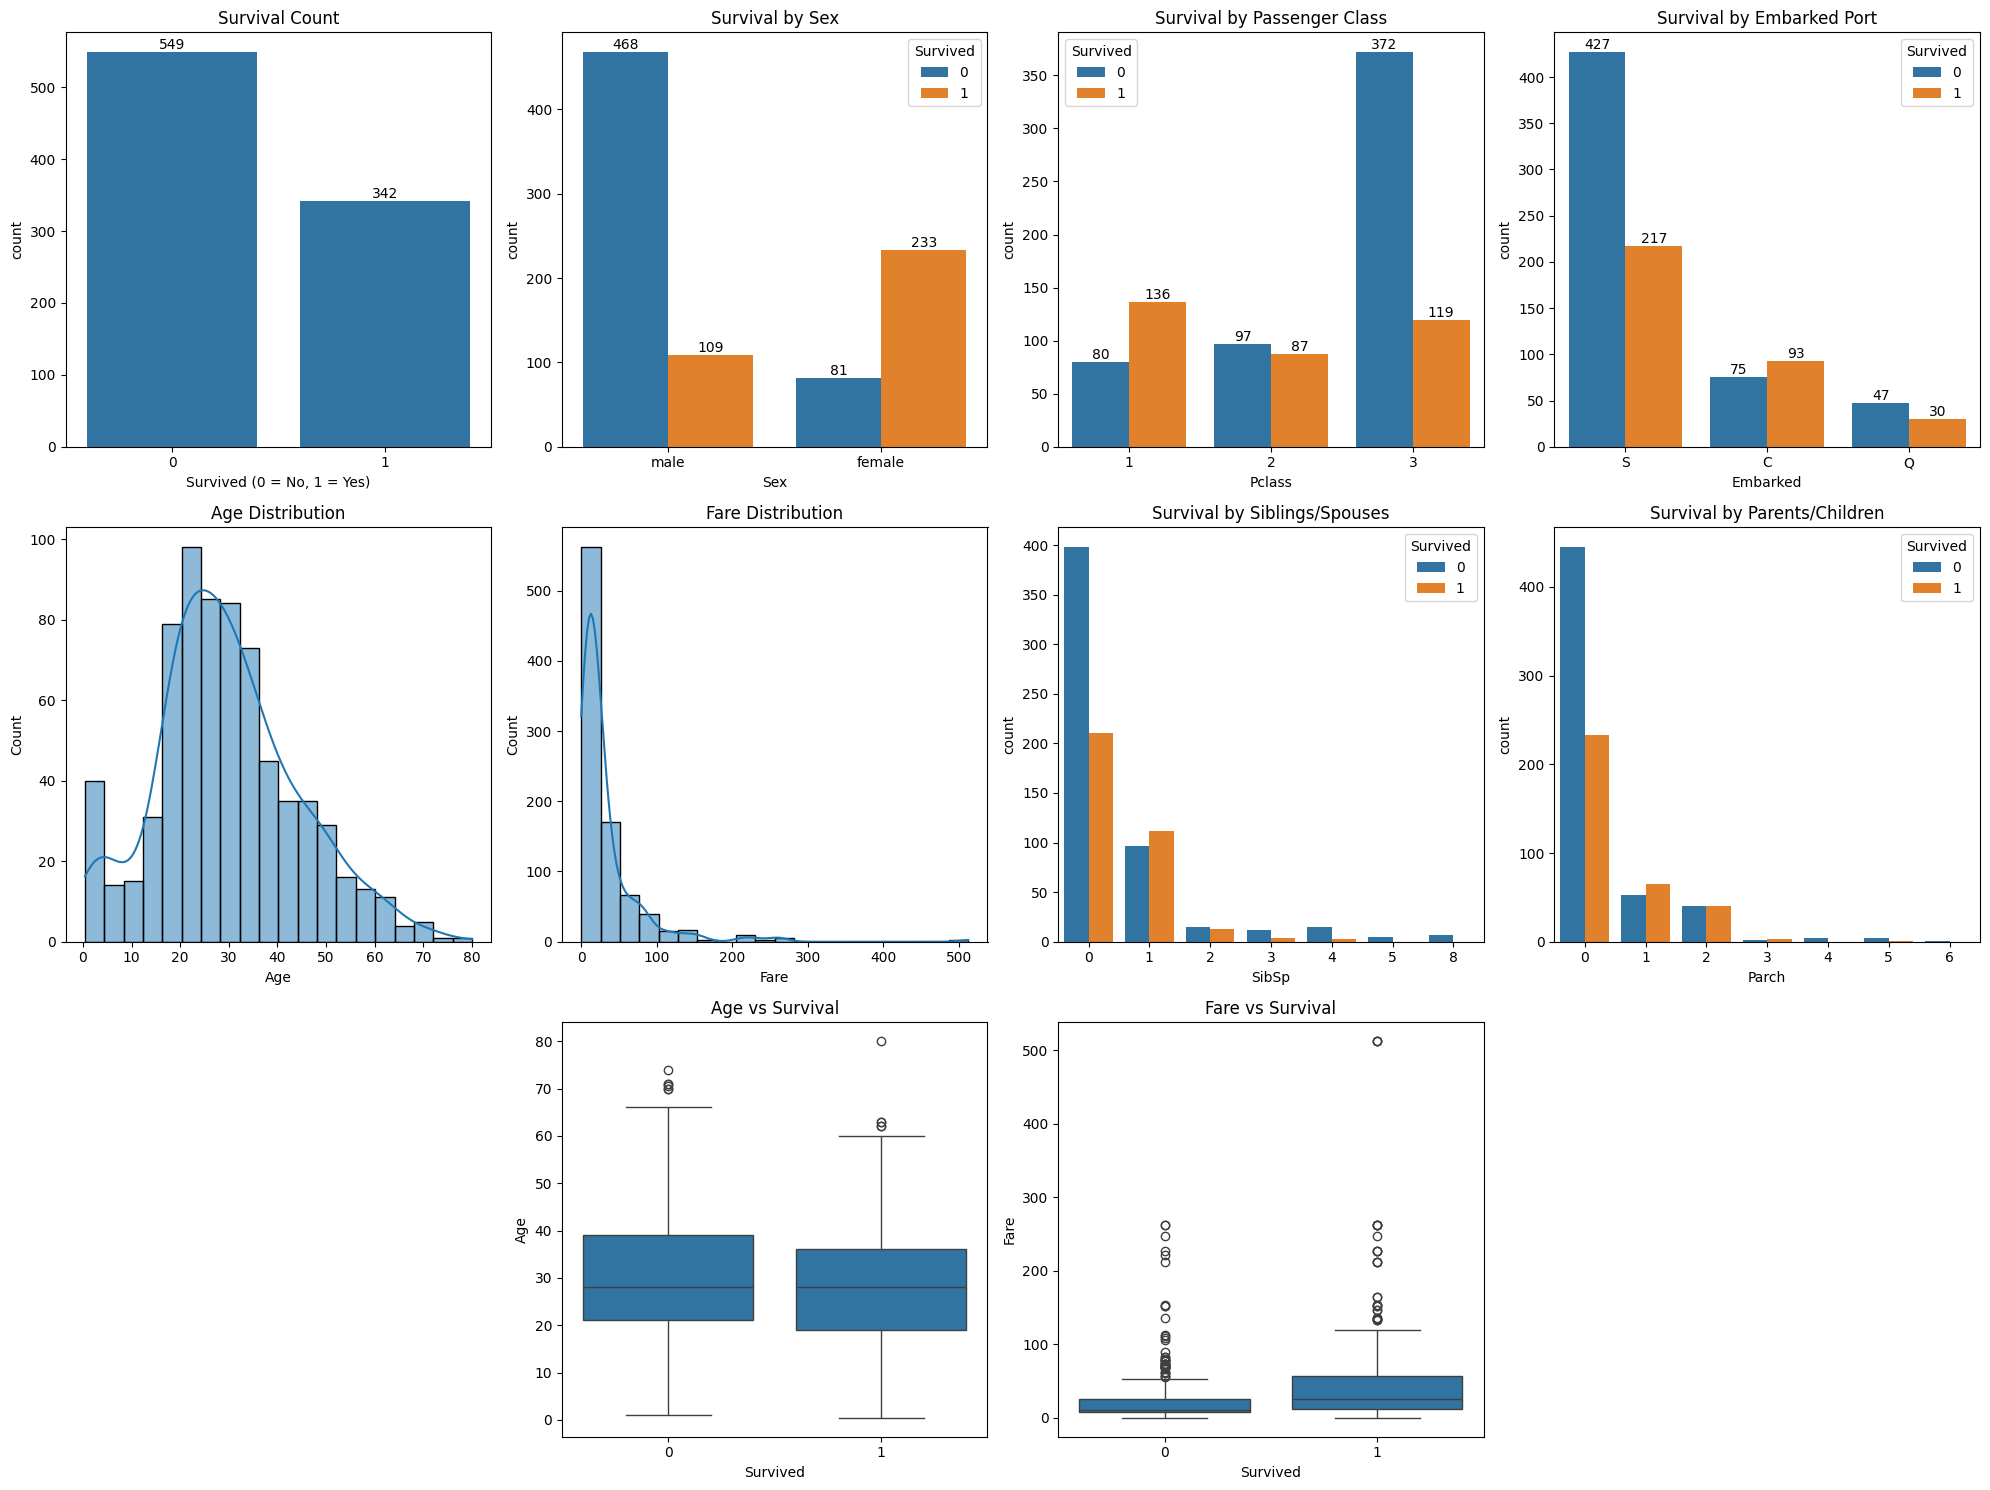

In [58]:
# Visualization
plt.figure(figsize=(20, 15))

# 1. Survival Count
plt.subplot(3, 4, 1)
ax1 = sns.countplot(x='Survived', data=train_df)
for p in ax1.patches:
    count = int(p.get_height())
    if count > 0:
        ax1.annotate(str(count), (p.get_x() + p.get_width() / 2., count), 
                     ha='center', va='bottom', fontsize=10)
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")

# 2. Survival by Sex
plt.subplot(3, 4, 2)
ax2 = sns.countplot(x='Sex', hue='Survived', data=train_df)
for p in ax2.patches:
    count = int(p.get_height())
    if count > 0:
        ax2.annotate(str(count), (p.get_x() + p.get_width() / 2., count), 
                     ha='center', va='bottom', fontsize=10)
plt.title("Survival by Sex")

# 3. Survival by Passenger Class
plt.subplot(3, 4, 3)
ax3 = sns.countplot(x='Pclass', hue='Survived', data=train_df)
for p in ax3.patches:
    count = int(p.get_height())
    if count > 0:
        ax3.annotate(str(count), (p.get_x() + p.get_width() / 2., count), 
                     ha='center', va='bottom', fontsize=10)
plt.title("Survival by Passenger Class")

# 4. Embarked vs Survival
plt.subplot(3, 4, 4)
ax4 = sns.countplot(x='Embarked', hue='Survived', data=train_df)
for p in ax4.patches:
    count = int(p.get_height())
    if count > 0:
        ax4.annotate(str(count), (p.get_x() + p.get_width() / 2., count), 
                     ha='center', va='bottom', fontsize=10)
plt.title("Survival by Embarked Port")

# 5. Age Distribution
plt.subplot(3, 4, 5)
sns.histplot(train_df['Age'], bins=20, kde=True)
plt.title("Age Distribution")

# 6. Fare Distribution
plt.subplot(3, 4, 6)
sns.histplot(train_df['Fare'], bins=20, kde=True)
plt.title("Fare Distribution")

# 7. Survival by SibSp
plt.subplot(3, 4, 7)
sns.countplot(x='SibSp', hue='Survived', data=train_df)
plt.title("Survival by Siblings/Spouses")

# 8. Survival by Parch
plt.subplot(3, 4, 8)
sns.countplot(x='Parch', hue='Survived', data=train_df)
plt.title("Survival by Parents/Children")

# 9. Age vs Survival
plt.subplot(3, 4, 10)
sns.boxplot(x='Survived', y='Age', data=train_df)
plt.title("Age vs Survival")

# 10. Fare vs Survival
plt.subplot(3, 4, 11)
sns.boxplot(x='Survived', y='Fare', data=train_df)
plt.title("Fare vs Survival")

plt.tight_layout()
plt.show()

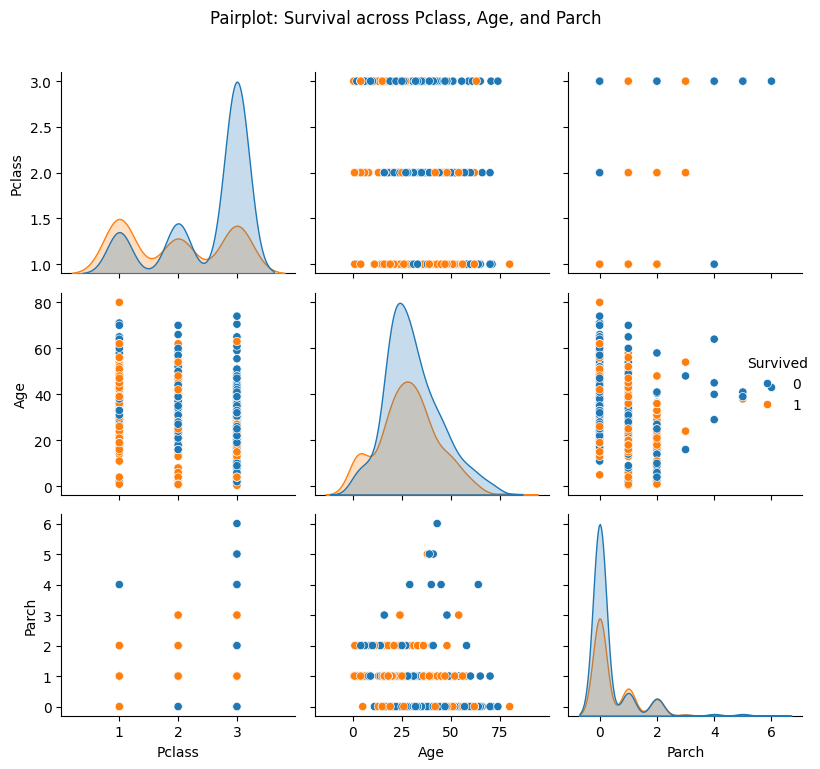

In [59]:
# Evaluating the relationships between features
sns.pairplot(train_df[['Survived', 'Pclass', 'Age', 'Parch']], hue='Survived')
plt.gcf().suptitle('Pairplot: Survival across Pclass, Age, and Parch', fontsize=12, y=1.02)

plt.tight_layout()
plt.show()

The pairplots indicate that passengers in higher fare classes survived at higher rates. We note no major trends in other combinations.

In [60]:
for col in train_df.select_dtypes(include=['object']).columns:
    print(f"Unique values in '{col}': {train_df[col].nunique()}")

Unique values in 'Name': 891
Unique values in 'Sex': 2
Unique values in 'Ticket': 681
Unique values in 'Cabin': 147
Unique values in 'Embarked': 3


Our general understanding is that `PassengerId`, `Name`, `Ticket` and `Cabin` features do not have an impact on survival status. Therefore, we will be dropping them from further evaluation

In [61]:
train_df = train_df.drop(['PassengerId', 'Cabin', 'Name', 'Ticket'], axis=1)
test_df = test_df.drop(['PassengerId', 'Cabin', 'Name', 'Ticket'], axis=1)

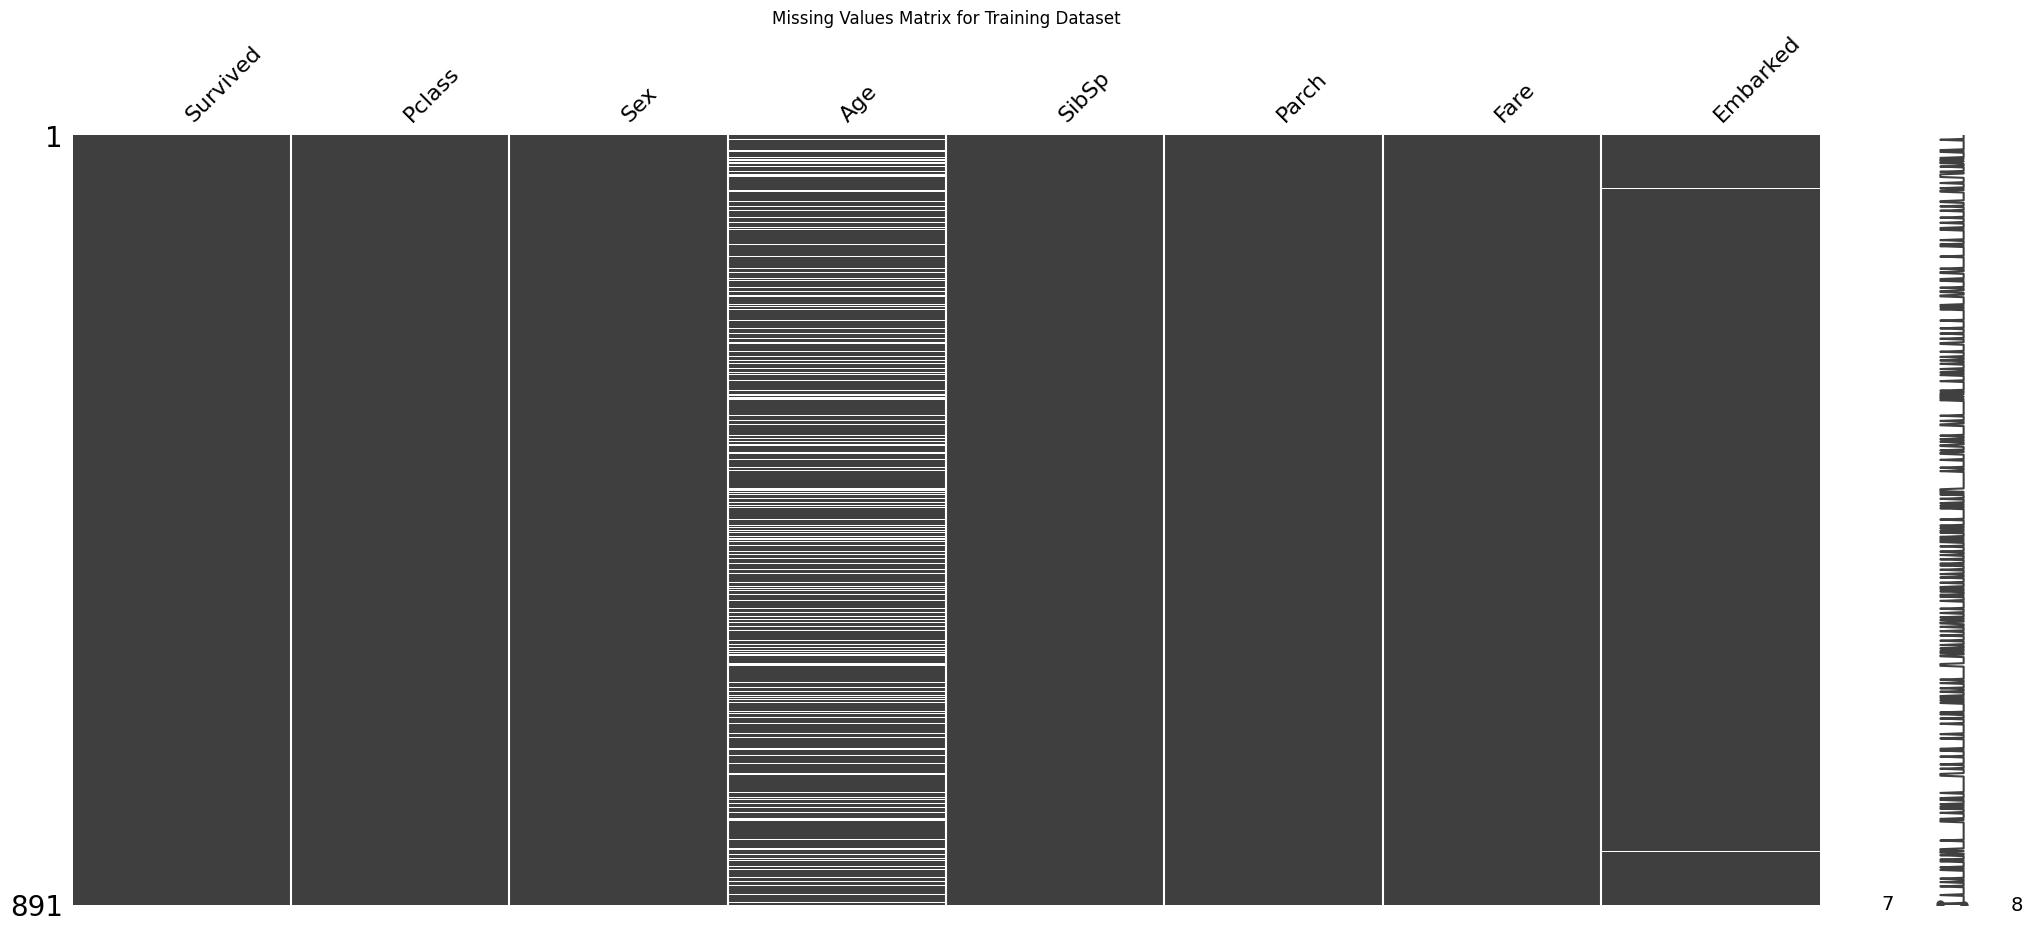

In [62]:
# Visualizing distribution of missing values
missingno.matrix(train_df)
plt.title('Missing Values Matrix for Training Dataset')
plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

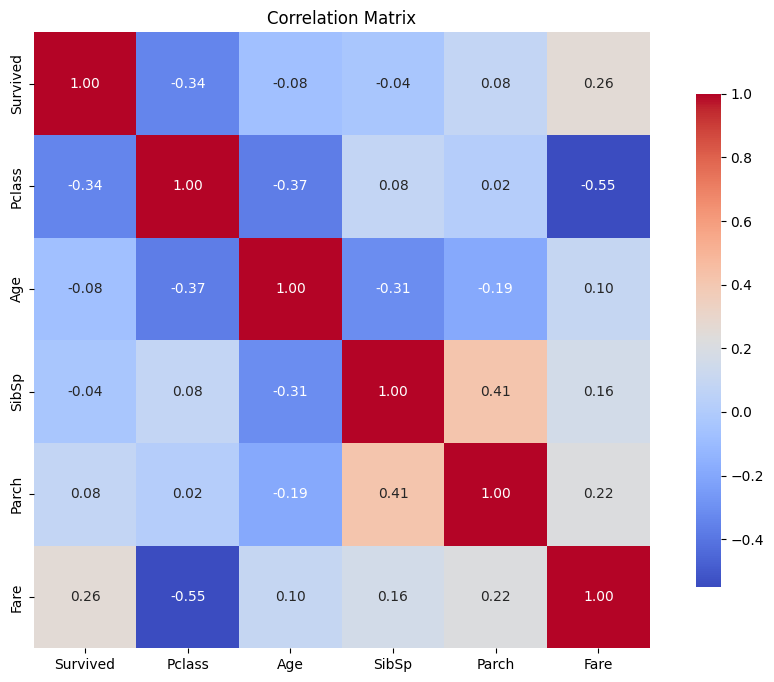

In [63]:
# Correlation Matrix
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12, 8))
correlation_matrix = train_df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix")

### 2. Feature Engineering

We have missing values in `Age` & `Embarked` columns. We will impute the `Age` using the median, `Fare` using the median by passenger class and the `Embarked` detail with `S` = `Southampton` since it is the most frequent value.

In [64]:
# Impute missing Age values using the median Age for each Pclass
train_df['Age'] = train_df['Age'].transform(lambda x: x.fillna(x.median()))
train_df['Fare'] = train_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
train_df['Embarked'] = train_df['Embarked'].fillna('S')

# Impute missing Age values in test set
test_df['Age'] = test_df['Age'].transform(lambda x: x.fillna(x.median()))
test_df['Fare'] = test_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
test_df['Embarked'] = test_df['Embarked'].fillna('S')

Missing values are now zero across the datasets. Now, we will convert categorical values into numeric values by encoding each unique value

In [65]:
# Convert categorical variables to numerical by mapping features
train_df['Sex'] = train_df['Sex'].map({'male': 0, 'female': 1})
train_df['Embarked'] = train_df['Embarked'].fillna('S')
train_df['Embarked'] = train_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
train_df['Fare'] = train_df['Fare'].fillna(train_df['Fare'].median())
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
test_df['Embarked'] = test_df['Embarked'].fillna('S')
test_df['Embarked'] = test_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

In [66]:
# Adding FamilySize feature that is created by summing the number of siblings/spouses (SibSp) and parents/children (Parch) aboard, plus one for the individual themselves.
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
train_df = train_df.drop(['SibSp', 'Parch'], axis=1) # Drop SibSp and Parch as they are now redundant

test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df = test_df.drop(['SibSp', 'Parch'], axis=1) # Drop SibSp and Parch as they are now redundant

In [67]:
# Missing values
print("Are there any missing values in the dataset?")
print("Training Dataset:", train_df.isnull().values.any())
print("Test Dataset:", test_df.isnull().values.any())

Are there any missing values in the dataset?
Training Dataset: False
Test Dataset: False


In [68]:
# Display the data types of the columns
print("Data Types of Training Dataset:")
print(train_df.dtypes)
print("\nData Types of Test Dataset:")
print(test_df.dtypes)

Data Types of Training Dataset:
Survived        int64
Pclass          int64
Sex             int64
Age           float64
Fare          float64
Embarked        int64
FamilySize      int64
dtype: object

Data Types of Test Dataset:
Pclass          int64
Sex             int64
Age           float64
Fare          float64
Embarked        int64
FamilySize      int64
dtype: object


All selected features are now numeric. 

### 3. Modeling

In [69]:
# Creating feature set X and target variable y
X = train_df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']]
y = train_df['Survived']
X_test = test_df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']]

In [70]:
# Scaling Age, Fare and FamilySize as they are continuous variables
scaler = StandardScaler()
X[['Age', 'Fare', 'FamilySize']] = scaler.fit_transform(X[['Age', 'Fare', 'FamilySize']]) 
X_test[['Age', 'Fare', 'FamilySize']] = scaler.transform(X_test[['Age', 'Fare', 'FamilySize']])

In [71]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#### 3.1 Random Forest Classifier

In [72]:
# Hyperparameter tuning for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 8, 10, 20, 30],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 8],
    'criterion': ['gini', 'entropy']
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid_search.fit(X, y)
print(f"Best Random Forest parameters: {rf_grid_search.best_params_}")
print(f"Best Random Forest CV score: {rf_grid_search.best_score_:.4f}")

Best Random Forest parameters: {'criterion': 'entropy', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 20, 'n_estimators': 100}
Best Random Forest CV score: 0.8429


In [73]:
model_rf = rf_grid_search.best_estimator_
tprs_rf, fprs_rf, precs_rf, recs_rf, accs_rf, aucs_rf = [], [], [], [], [], []

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_rf.fit(X_train, y_train)
    y_pred = model_rf.predict(X_val)
    y_proba = model_rf.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    tprs_rf.append(tp / (tp + fn))
    fprs_rf.append(fp / (fp + tn))
    precs_rf.append(tp / (tp + fp) if tp + fp else 0)
    recs_rf.append(tp / (tp + fn) if tp + fn else 0)
    accs_rf.append(accuracy_score(y_val, y_pred))
    aucs_rf.append(roc_auc_score(y_val, y_proba))

fpr_rf, tpr_rf, _ = roc_curve(y, model_rf.predict_proba(X)[:, 1])
prec_rf, rec_rf, _ = precision_recall_curve(y, model_rf.predict_proba(X)[:, 1])

#### 3.2 Gradient Boosted Trees

In [74]:
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [3, 5, 7, 10],
    'criterion': ['friedman_mse', 'squared_error'],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

gb_grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid_search.fit(X, y)
print(f"Best Gradient Boosting parameters: {gb_grid_search.best_params_}")
print(f"Best Gradient Boosting CV score: {gb_grid_search.best_score_:.4f}")

Best Gradient Boosting parameters: {'criterion': 'friedman_mse', 'learning_rate': 0.01, 'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 300}
Best Gradient Boosting CV score: 0.8485


In [75]:
model_gb = gb_grid_search.best_estimator_
tprs_gb, fprs_gb, precs_gb, recs_gb, accs_gb, aucs_gb = [], [], [], [], [], []

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_gb.fit(X_train, y_train)
    y_pred = model_gb.predict(X_val)
    y_proba = model_gb.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    tprs_gb.append(tp / (tp + fn))
    fprs_gb.append(fp / (fp + tn))
    precs_gb.append(tp / (tp + fp) if tp + fp else 0)
    recs_gb.append(tp / (tp + fn) if tp + fn else 0)
    accs_gb.append(accuracy_score(y_val, y_pred))
    aucs_gb.append(roc_auc_score(y_val, y_proba))

fpr_gb, tpr_gb, _ = roc_curve(y, model_gb.predict_proba(X)[:, 1])
prec_gb, rec_gb, _ = precision_recall_curve(y, model_gb.predict_proba(X)[:, 1])

#### 3.3 Extra Trees

In [76]:
# Hyperparameter tuning for Extra Trees
et_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20, 30],
    'criterion': ['gini', 'entropy']
}

et_grid_search = GridSearchCV(
    ExtraTreesClassifier(random_state=42, n_jobs=-1),
    et_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

et_grid_search.fit(X, y)
print(f"Best Extra Trees parameters: {et_grid_search.best_params_}")
print(f"Best Extra Trees CV score: {et_grid_search.best_score_:.4f}")

Best Extra Trees parameters: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 300}
Best Extra Trees CV score: 0.8350


In [77]:
model_et = et_grid_search.best_estimator_
tprs_et, fprs_et, precs_et, recs_et, accs_et, aucs_et = [], [], [], [], [], []

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_et.fit(X_train, y_train)
    y_pred = model_et.predict(X_val)
    y_proba = model_et.predict_proba(X_val)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    tprs_et.append(tp / (tp + fn))
    fprs_et.append(fp / (fp + tn))
    precs_et.append(tp / (tp + fp) if tp + fp else 0)
    recs_et.append(tp / (tp + fn) if tp + fn else 0)
    accs_et.append(accuracy_score(y_val, y_pred))
    aucs_et.append(roc_auc_score(y_val, y_proba))

fpr_et, tpr_et, _ = roc_curve(y, model_et.predict_proba(X)[:, 1])
prec_et, rec_et, _ = precision_recall_curve(y, model_et.predict_proba(X)[:, 1])

### 4. Results

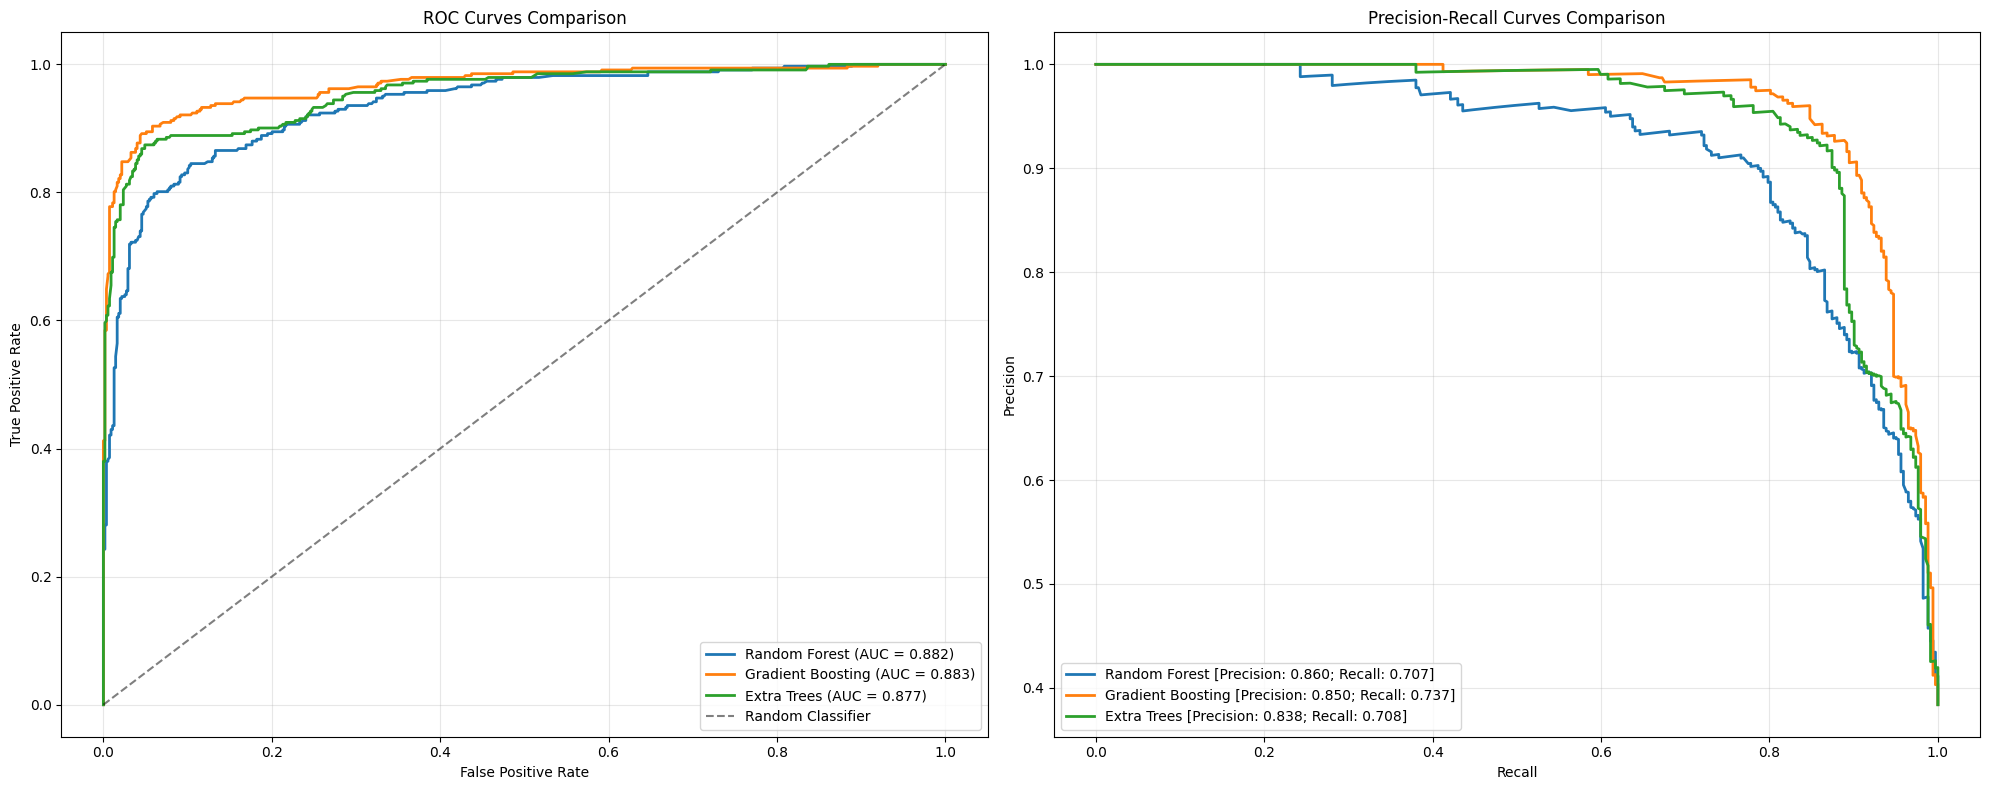

In [78]:
plt.figure(figsize=(20, 8))

# ROC Curves
plt.subplot(1, 2, 1)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {np.mean(aucs_rf):.3f})', linewidth=2)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {np.mean(aucs_gb):.3f})', linewidth=2)
plt.plot(fpr_et, tpr_et, label=f'Extra Trees (AUC = {np.mean(aucs_et):.3f})', linewidth=2)
# Add diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

# Precision-Recall Curves
plt.subplot(1, 2, 2)
plt.plot(rec_rf, prec_rf, label=f'Random Forest [Precision: {np.mean(precs_rf):.3f}; Recall: {np.mean(recs_rf):.3f}]', linewidth=2)
plt.plot(rec_gb, prec_gb, label=f'Gradient Boosting [Precision: {np.mean(precs_gb):.3f}; Recall: {np.mean(recs_gb):.3f}]', linewidth=2)
plt.plot(rec_et, prec_et, label=f'Extra Trees [Precision: {np.mean(precs_et):.3f}; Recall: {np.mean(recs_et):.3f}]', linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation of results**<br>

ROC Curve:
- This tells us how well our model can differentiate between 'survivors' and 'non-survivors'
- A model can tell the difference between these groups well if its AUC value is close to 1.0. 
- All models do well because their AUC scores are over 85%.

Precision-Recall Curve:
- This measures how each model performs on imbalanced data (more non-survivors than survivors)
- The higher the curves, the better the model is at precision-recall trade-offs
- All models are comparable in performance, though Logistic Regression has the best recall and KNN has the best precision

In [79]:
# Storing results
models_results = {}

models_results['Random Forest'] = {
    'TPR': np.mean(tprs_rf),
    'FPR': np.mean(fprs_rf),
    'Precision': np.mean(precs_rf),
    'Recall': np.mean(recs_rf),
    'Accuracy': np.mean(accs_rf),
    'AUC': np.mean(aucs_rf)
}

models_results['Gradient Boosting'] = {
    'TPR': np.mean(tprs_gb),
    'FPR': np.mean(fprs_gb),
    'Precision': np.mean(precs_gb),
    'Recall': np.mean(recs_gb),
    'Accuracy': np.mean(accs_gb),
    'AUC': np.mean(aucs_gb)
}

models_results['Extra Trees'] = {
    'TPR': np.mean(tprs_et),
    'FPR': np.mean(fprs_et),
    'Precision': np.mean(precs_et),
    'Recall': np.mean(recs_et),
    'Accuracy': np.mean(accs_et),
    'AUC': np.mean(aucs_et)
}

comparison_df = pd.DataFrame(models_results).T
comparison_df = comparison_df.round(3)
display(comparison_df)

,TPR,FPR,Precision,Recall,Accuracy,AUC
Random Forest,0.707,0.073,0.860,0.707,0.843,0.882
Gradient Boosting,0.737,0.082,0.850,0.737,0.848,0.883
Extra Trees,0.708,0.086,0.838,0.708,0.835,0.877


### 5. Model Evaluation

#### 5.1 Random Forest Classifier

1. **What we check**: We check if the model relies on the same features, how it performs on unseen data, and if it overfits.

2. **Why it matters**: These issues could cause errors when the model is used on real-world, unseen data. 

3. **How we check it**: We check feature importance through bootstrap sampling and analyze accuracy over multiple cuts of unseen data. We also check if the model overfits by predicting with and without cross-validation and comparing the accuracy scores.

In [80]:
# Check feature importance stability through bootstrap
print("1. Feature Importance Stability Check:")
importance_bootstrap = []
for i in range(50):
    X_boot, y_boot = resample(X, y, random_state=i)
    rf_boot = RandomForestClassifier(n_estimators=100, random_state=i, criterion = 'entropy', 
                                     max_depth = 20, max_features='sqrt', min_samples_leaf = 2,
                                     min_samples_split = 20)
    rf_boot.fit(X_boot, y_boot)
    importance_bootstrap.append(rf_boot.feature_importances_)

importance_std = np.std(importance_bootstrap, axis=0)
stability_df = pd.DataFrame({
    'feature': X.columns,
    'mean_importance': np.mean(importance_bootstrap, axis=0),
    'std_importance': importance_std,
    'stability_ratio': np.mean(importance_bootstrap, axis=0) / importance_std
}).sort_values('mean_importance', ascending=False)

print(stability_df)

1. Feature Importance Stability Check:
      feature  mean_importance  std_importance  stability_ratio
1         Sex         0.338155        0.029259        11.557133
3        Fare         0.238164        0.014543        16.376290
2         Age         0.194845        0.014584        13.360198
0      Pclass         0.110004        0.016929         6.497889
5  FamilySize         0.083146        0.011201         7.422827
4    Embarked         0.035686        0.006920         5.157167


In [81]:
# Out-of-Bag (OOB) Error
print("2. Out-of-Bag Error Analysis:")
rf_oob = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf_oob.fit(X, y)
print(f"OOB Score: {rf_oob.oob_score_:.4f}")
print(f"OOB Error: {1 - rf_oob.oob_score_:.4f}")

2. Out-of-Bag Error Analysis:
OOB Score: 0.8193
OOB Error: 0.1807


*Out-of-Bag (OOB) Error Interpretation*

- The model has predicted survival accurately in ~82% of cases where the sample was not included during training (i.e., "out-of-bag" samples).
- The OOB score is a reliable estimate of model performance, similar to cross-validation, but does not require separate validation. This is done to confirm whether the model is overfitting.

In [82]:
# Tree Depth and Overfitting Check
print("3. Overfitting Assessment:")
train_scores = []
val_scores = []

rf_temp = rf_grid_search.best_estimator_
train_score = np.mean(cross_val_score(rf_temp, X, y, cv=5, scoring='accuracy'))
rf_temp.fit(X, y)
train_acc = rf_temp.score(X, y)

overfit_gap = train_acc - train_score

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Cross-Validation Accuracy: {train_score:.2%}")
print(f"Overfit Gap: {overfit_gap:.2f}")
if round(overfit_gap) < 0.1:
    print("The model does not appear to be overfitting.")
elif round(overfit_gap) < 0.2:
    print("The model shows marginal signs of overfitting.")
else:
    print("The model shows significant signs of overfitting.")

3. Overfitting Assessment:
Training Accuracy: 88.10%
Cross-Validation Accuracy: 81.82%
Overfit Gap: 0.06
The model does not appear to be overfitting.


#### 5.2 Gradient Boosted Trees

1. **What we check**: We assess whether the model learns effectively without overfitting, and how sensitive it is to changes in learning rate and number of estimators (trees).

2. **Why it matters**: Gradient Boosted Trees iteratively build trees to reduce errors and can overfit if it learns too quickly/slowly. Evaluating learning progress helps us ensure the model performs robustly.

3. **How we check it**: We track how the model's training loss decreases over iterations, compare training and validation accuracy and test different learning rates via cross-validation.

In [83]:
print("1. Learning Rate vs Number of Estimators:")
model_gb.fit(X, y)

# Check training deviance (loss) evolution
train_scores = model_gb.train_score_
print(f"First model accuracy: {train_scores[-1]:.2%}")
print(f"Training improvement: {train_scores[0] - train_scores[-1]:.2%}")

1. Learning Rate vs Number of Estimators:
First model accuracy: 44.79%
Training improvement: 87.23%


Here, final training deviance of 44.79% means the initial model learns patterns well without overfitting and improves 87.23% through training. 

In [84]:
print("2. Overfitting Detection (Staged Predictions):")
# Evaluate accuracy
train_acc = accuracy_score(y_train, model_gb.predict(X_train))
val_acc = accuracy_score(y_val, model_gb.predict(X_val))

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Validation Accuracy: {val_acc:.2%}")

2. Overfitting Detection (Staged Predictions):
Training Accuracy: 93.27%
Validation Accuracy: 94.94%


The model shows very similar performance on both training and validation datasets, indicating that the Gradient Boosting model is not overfitting.

In [85]:
print("3. Learning Rate Sensitivity:")
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
lr_performance = []

for lr in learning_rates:
    gbt_lr = GradientBoostingClassifier(learning_rate=lr, n_estimators=300, random_state=42, max_depth = 7, max_features='sqrt', criterion= 'friedman_mse')
    cv_score = np.mean(cross_val_score(gbt_lr, X, y, cv=5, scoring='accuracy'))
    lr_performance.append(cv_score)

lr_df = pd.DataFrame({
    'learning_rate': learning_rates,
    'cv_accuracy': lr_performance
})
print(lr_df)

3. Learning Rate Sensitivity:
   learning_rate  cv_accuracy
0           0.01     0.827199
1           0.05     0.811481
2           0.10     0.812592
3           0.20     0.806980
4           0.30     0.803603


We see that cross-validation accuracy is consistent across learning rates.

#### 5.3 Extra Trees

1. **What we check**: We check if features are informative and confirm that they are not highly correlated. We also check if the data has outliers.

2. **Why it matters**:  Extra Trees use feature thresholds to build randomized decision trees. This can become unstable if there are features are irrelevant, highly correlated, or contain outliers.

3. **How we check/control for it**: We measure feature relevance through bootstrapping, multicollinearity through VIF, and statistical tests to identify if features have outliers.

In [86]:
# Check feature importance stability through bootstrap
print("1. Feature Importance Stability Check:")
importance_bootstrap = []
for i in range(50):
    X_boot, y_boot = resample(X, y, random_state=i)
    et_boot = ExtraTreesClassifier(n_estimators=300, random_state=i, criterion = 'gini', max_depth= 10, max_features='sqrt')
    et_boot.fit(X_boot, y_boot)
    importance_bootstrap.append(et_boot.feature_importances_)

importance_std = np.std(importance_bootstrap, axis=0)
stability_df = pd.DataFrame({
    'feature': X.columns,
    'mean_importance': np.mean(importance_bootstrap, axis=0),
    'std_importance': importance_std,
    'stability_ratio': np.mean(importance_bootstrap, axis=0) / importance_std
}).sort_values('mean_importance', ascending=False)

print(stability_df)

1. Feature Importance Stability Check:
      feature  mean_importance  std_importance  stability_ratio
1         Sex         0.424491        0.036893        11.505949
0      Pclass         0.148547        0.022724         6.537021
2         Age         0.147665        0.012874        11.469618
3        Fare         0.146163        0.010770        13.571674
5  FamilySize         0.090131        0.010758         8.378094
4    Embarked         0.043003        0.008476         5.073487


`Sex` is the most important feature and also the most stable, meaning it is the most reliable predictor. Next, `Pclass`, `Age`, and `Fare` are consistently important, but `FamilySize` and `Embarked` do not seem very important in this model. This means that they might be sensitive to sample variation. 

In [87]:
# 2. Check for outliers in scaled continuous features (z-score method)
z_scores = np.abs(zscore(X[['Age', 'Fare', 'FamilySize']]))
outliers = (z_scores > 3).any(axis=1)
print(f"Number of rows with outliers in continuous features: {outliers.sum()} out of {len(X)}")

Number of rows with outliers in continuous features: 52 out of 891


In [88]:
# Identify which feature(s) are outliers for each row
feature_names = ['Age', 'Fare', 'FamilySize']
outlier_features = []

# Create an OutlierFlag column: 1 if any feature is an outlier, else 0
train_df['OutlierFlag'] = (np.abs(z_scores) > 3).any(axis=1).astype(int)

for row in z_scores:
    features = [feature_names[i] for i, val in enumerate(row) if val > 3]
    outlier_features.append(', '.join(features) if features else '')

train_df['OutlierFeature'] = outlier_features

# Display rows with outliers and the corresponding feature(s)
print(train_df[['Pclass', 'Age', 'Fare', 'FamilySize', 'OutlierFlag', 'OutlierFeature']][train_df['OutlierFlag'] == 1])

     Pclass   Age      Fare  FamilySize  OutlierFlag OutlierFeature
13        3  39.0   31.2750           7            1     FamilySize
25        3  38.0   31.3875           7            1     FamilySize
27        1  19.0  263.0000           6            1           Fare
59        3  11.0   46.9000           8            1     FamilySize
68        3  17.0    7.9250           7            1     FamilySize
71        3  16.0   46.9000           8            1     FamilySize
88        1  23.0  263.0000           6            1           Fare
96        1  71.0   34.6542           1            1            Age
116       3  70.5    7.7500           1            1            Age
118       1  24.0  247.5208           2            1           Fare
119       3   2.0   31.2750           7            1     FamilySize
159       3  28.0   69.5500          11            1     FamilySize
180       3  28.0   69.5500          11            1     FamilySize
182       3   9.0   31.3875           7         

On examination, outliers in `Fare` pertain to first class fares, which are expected to be higher than general. `Age` outliers are for older than usual passengers but nothing abnormal per our understanding. `FamilySize` outliers are also not unrealistic. There would be families immigrating or on vacation. 

In [89]:
# VIF (Variance Inflation Factor) for multicollinearity
print("3. Multicollinearity Check using VIF:")
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

3. Multicollinearity Check using VIF:
      feature       VIF
0      Pclass  1.786395
1         Sex  1.556143
2         Age  1.099673
3        Fare  1.221483
4    Embarked  1.387202
5  FamilySize  1.176519


None of the VIF values are higher than 5, suggesting no major multicollinearity.

#### 5.4 Feature Importance by Model

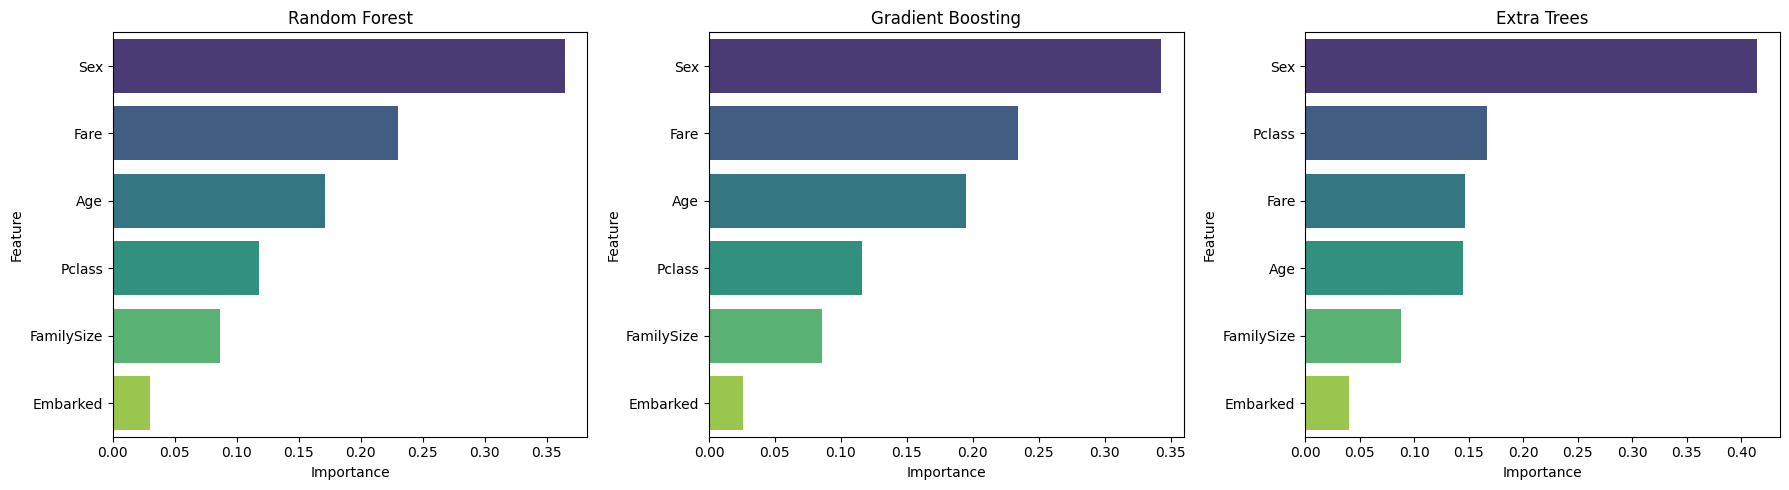

In [90]:
# Random Forest
rf_feature_importance = model_rf.feature_importances_
feature_names = X.columns
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_feature_importance
}).sort_values(by='Importance', ascending=False)

# Gradient Boosting
gb_feature_importance = model_gb.feature_importances_
gb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_feature_importance
}).sort_values(by='Importance', ascending=False)

# Extra Trees
et_feature_importance = model_et.feature_importances_
et_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': et_feature_importance
}).sort_values(by='Importance', ascending=False)

# Plot all three side by side
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis')
plt.title('Random Forest')

plt.subplot(1, 3, 2)
sns.barplot(x='Importance', y='Feature', data=gb_importance_df, palette='viridis')
plt.title('Gradient Boosting')

plt.subplot(1, 3, 3)
sns.barplot(x='Importance', y='Feature', data=et_importance_df, palette='viridis')
plt.title('Extra Trees')

plt.tight_layout()
plt.show()

Observing the feature importance charts, we note that the passenger's sex was far more important in predicting their survival, followed by fare (which is generally a proxy for passenger class) and passenger class. 

#### 5.5 Confusion Matrix

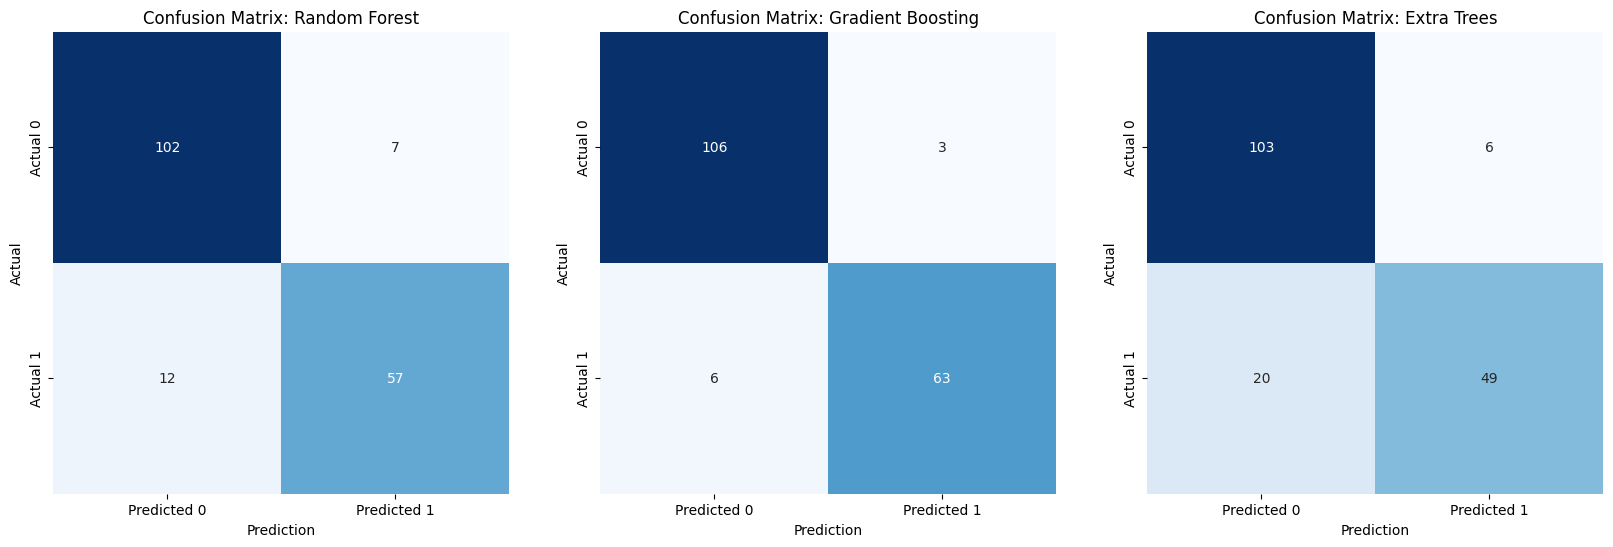

In [91]:
# Random Forest Confusion Matrix
y_pred_rf = model_rf.predict(X_val)
cm_rf = confusion_matrix(y_val, y_pred_rf)

# Gradient Boosting Confusion Matrix
y_pred_gb = model_gb.predict(X_val)
cm_gb = confusion_matrix(y_val, y_pred_gb)

# Extra Trees Confusion Matrix
y_pred_et = model_et.predict(X_val)
cm_et = confusion_matrix(y_val, y_pred_et)

# Plotting confusion matrices
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Prediction')
plt.ylabel('Actual')

plt.subplot(1, 3, 2)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: Gradient Boosting')
plt.xlabel('Prediction')
plt.ylabel('Actual')

plt.subplot(1, 3, 3)
sns.heatmap(cm_et, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: Extra Trees')
plt.xlabel('Prediction')
plt.ylabel('Actual')

plt.show()

The confusion matrices tell us that the model generally can predict deaths much better than survivals. This could be due to the inherent imbalance in the dataset. 

### 6. Predictions

In [92]:
model_rf.fit(X, y)
test_pred = model_rf.predict(X_test)
submission = pd.DataFrame({
    "PassengerId": passenger_id,
    "Survived": test_pred
})
submission.to_csv("random_forest_titanic_submission.csv", index=False)

In [93]:
model_gb.fit(X, y)
test_pred = model_gb.predict(X_test)
submission = pd.DataFrame({
    "PassengerId": passenger_id,
    "Survived": test_pred
})
submission.to_csv("gradient_boosting_titanic_submission.csv", index=False)

In [94]:
model_et.fit(X, y)
test_pred = model_et.predict(X_test)
submission = pd.DataFrame({
    "PassengerId": passenger_id,
    "Survived": test_pred
})
submission.to_csv("extra_trees_titanic_submission.csv", index=False)

### 7. Discussion of model results in layman terms

We deployed three different classifier models to predict which passengers would survive the Titanic disaster, using these passenger features: ticket class, gender, age, fare paid, port of embarkation, and family size.

*Model Performance at a Glance*

All three models were about the same in terms of accuracy (~85%). However, the models had varying Precision and Recall rates.  Higher precision means that we would have fewer false positives, i.e., a passenger who did not survive would not be classified as a survivor. 

*Key Performance Differences*

Precision: Precision tells us "When the model predicts that a passenger survived, how often does it get that right?". On this metric:

1. Gradient Boosting: Scored best at 85%, showing that it would be the most reliable model to predict passenger survival
2. Random Forest and Extra Trees: Scored similarly at ~84%

Recall: Recall tells us: "Of those who survived, how many did we correctly identify?". Higher recall means we miss fewer survivors. 

1. Random Forest and Gradient Boosting: Scored best at 73.7%, meaning they would identify the most number of survivors
2. Extra Trees: Scored lower at 70.8%.

Since all models perform at similar levels, we believe that model choice will ultimatel depend on prediction priorities. We recommend stakeholders to:
1. Choose Gradient Boosting if it's more important to identify as many survivors as possible, even if it means some false positives.
2. Choose Random Forest if it's more important to be confident in survival predictions, even if it means it missing some survivors.
3. Choose Extra Trees if it's important to have a quick model which generalizes well to unseen data.

## Appendix 2: Kaggle Profile and Submissions

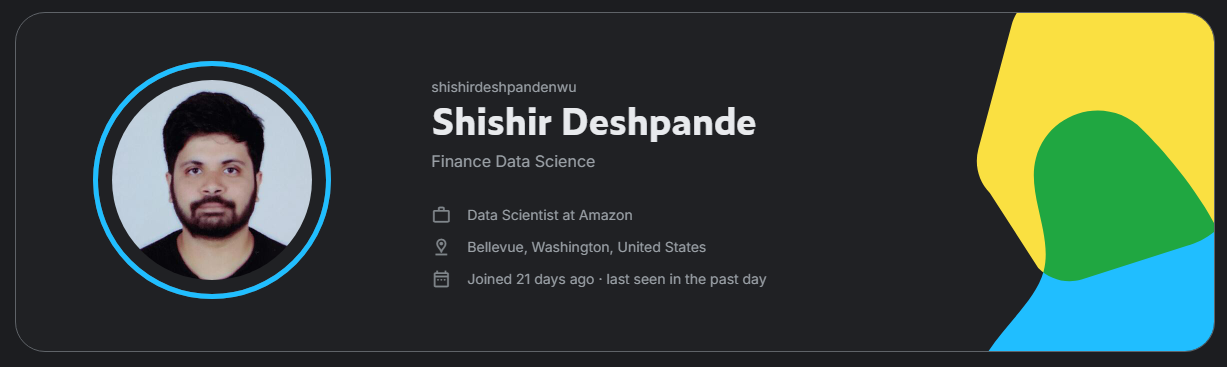

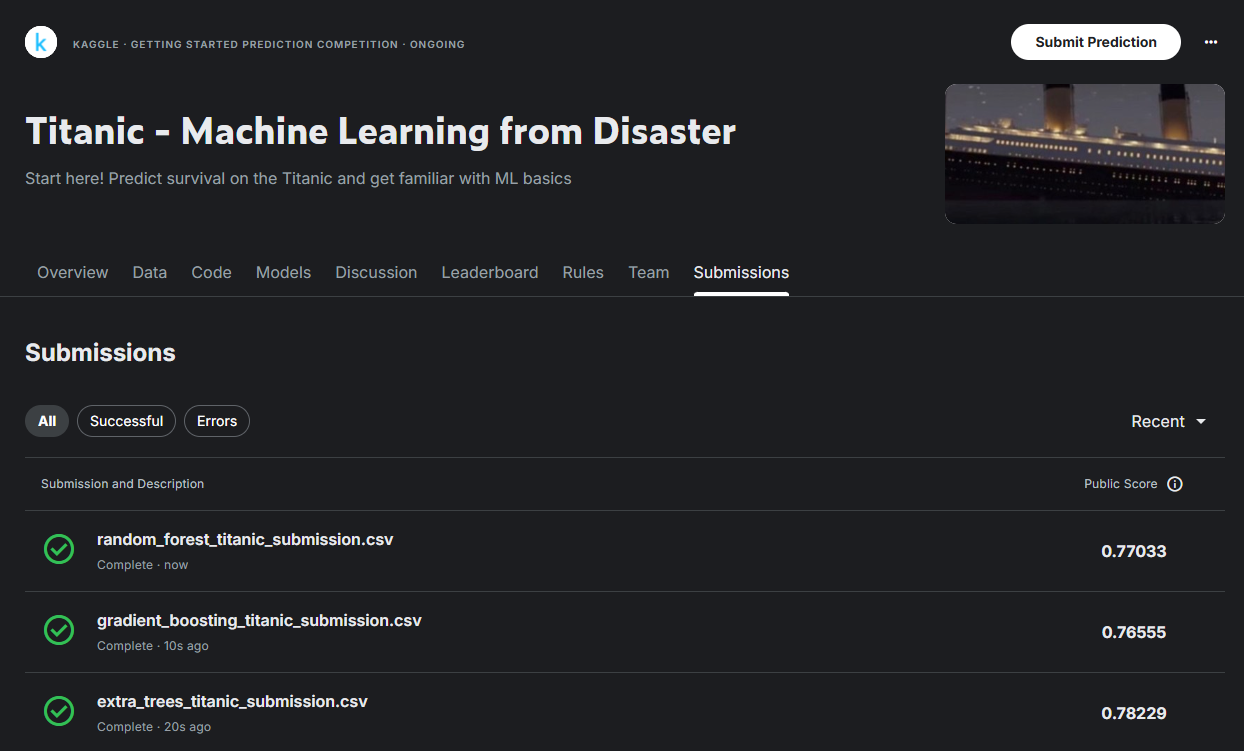